In [28]:
import torch 
import torchvision
from torchvision import transforms
import os 
from PIL import Image
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 
import numpy as np 

In [35]:
class ImageProcessor:
    def __init__(self,root_path,transformation=None):
        self.root_path = root_path
        self.transformation = transformation

        #from root path get list for all imgs 
        self.all_img_path = [os.path.join(root_path,img) for img in os.listdir(root_path)]

    def __len__(self):
        return len(self.all_img_path)

    def __getitem__(self,idx):
        img_path = self.all_img_path[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transformation:
            img= self.transformation(img)
        return img

In [36]:
root_path = "img_align_celeba/"
transformation = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [37]:
dataset = ImageProcessor(root_path,transformation)
print(f"loaded {len(dataset)} images")

loaded 104362 images


In [38]:
dataloader = DataLoader(dataset,batch_size=108,shuffle=True)

In [39]:
class Generator(nn.Module):
    def __init__(self,z_dim=100,img_channel=3): 
        super().__init__()

        #fully connected layer--
        self.model = nn.Sequential(
            #1st layer
            nn.Linear(z_dim,256), 
            nn.ReLU(),

            #2ndlayer
            nn.Linear(256,512), 
            nn.ReLU(),

            #3rdLayer
            nn.Linear(512,1024), 
            nn.ReLU(),

            #4thLayer
            nn.Linear(1024,64*64*img_channel),
            nn.Tanh(),
        )

    def forward(self,z):
        img = self.model(z)
        img =img.view(img.size(0),3,64,64)
        return img

In [40]:
class Discriminator(nn.Module):
    def __init__(self,img_channel=3): 
        super().__init__()

        #fully connected layer 
        self.model = nn.Sequential(
            nn.Flatten(), 
            
            nn.Linear(img_channel*64*64,1024), 
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True), 

            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,img):
        return self.model(img)

In [47]:
Gan_loss = nn.BCELoss()
generator = Generator()
g_optim = optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))

discriminator = Discriminator()
d_optim = optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [42]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [43]:
generator = generator.to(device)
discriminator = discriminator.to(device)

In [49]:
def train(generator,discriminator,dataloader,epochs=10):
    
    for epoch in range(epochs):
        for i , imgs in enumerate(dataloader):
            real_img = imgs.to(device)
            batch_size = real_img.size(0)
            fake_img = generator(torch.randn(batch_size,100).to(device))

            #create realimg label and fakeimg label
            real_labels = torch.ones(batch_size,1).to(device)
            fake_labels = torch.zeros(batch_size,1).to(device)

            #train discriminator
            d_optim.zero_grad() 
            real_loss = Gan_loss(discriminator(real_img),real_labels)
            fake_loss = Gan_loss(discriminator(fake_img.detach()),fake_labels)

            d_loss = (real_loss+fake_loss)/2 
            d_loss.backward() 
            d_optim.step()

            #train generator
            g_optim.zero_grad()
            g_loss = Gan_loss(discriminator(fake_img),real_labels)
            g_loss.backward()
            g_optim.step()

            if i%50 ==0:
                print(f"for epoch: {epoch+1}/{epochs}.....batch: {i+1}...g_loss: {g_loss}.....d_loss:{d_loss}")
                
        save_gen_img(generator,epoch,device)

In [51]:
def save_gen_img(generator,epoch,device,num_imgs=8): 
    z = torch.randn(num_imgs,100).to(device)
    gen_imgs = generator(z).detach().cpu()
    grid = torchvision.utils.make_grid(gen_imgs,nrow=4,normalize=True)
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.title(f"epoch:{epoch+1}")
    plt.show()

for epoch: 1/10.....batch: 1...g_loss: 0.7372252941131592.....d_loss:0.6988828778266907
for epoch: 1/10.....batch: 51...g_loss: 1.1656891107559204.....d_loss:0.2882893979549408
for epoch: 1/10.....batch: 101...g_loss: 2.1400258541107178.....d_loss:0.1181139349937439
for epoch: 1/10.....batch: 151...g_loss: 2.122511148452759.....d_loss:0.15540073812007904
for epoch: 1/10.....batch: 201...g_loss: 1.991106390953064.....d_loss:0.15534403920173645
for epoch: 1/10.....batch: 251...g_loss: 3.5411555767059326.....d_loss:0.025024443864822388
for epoch: 1/10.....batch: 301...g_loss: 2.751725912094116.....d_loss:0.06736916303634644
for epoch: 1/10.....batch: 351...g_loss: 0.6412999033927917.....d_loss:0.21318547427654266
for epoch: 1/10.....batch: 401...g_loss: 1.5983229875564575.....d_loss:0.43629494309425354
for epoch: 1/10.....batch: 451...g_loss: 2.8138439655303955.....d_loss:0.07372680306434631
for epoch: 1/10.....batch: 501...g_loss: 3.3610332012176514.....d_loss:0.0773279070854187
for epoc

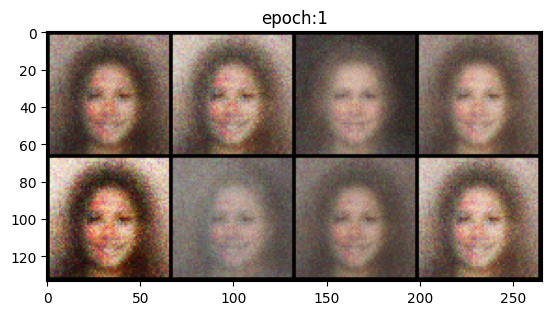

for epoch: 2/10.....batch: 1...g_loss: 6.16679048538208.....d_loss:0.40792930126190186
for epoch: 2/10.....batch: 51...g_loss: 2.8817667961120605.....d_loss:0.24648979306221008
for epoch: 2/10.....batch: 101...g_loss: 1.636264681816101.....d_loss:0.4370294213294983
for epoch: 2/10.....batch: 151...g_loss: 3.151067018508911.....d_loss:0.19556140899658203
for epoch: 2/10.....batch: 201...g_loss: 3.802851438522339.....d_loss:0.5229752659797668
for epoch: 2/10.....batch: 251...g_loss: 3.128061532974243.....d_loss:0.15310899913311005
for epoch: 2/10.....batch: 301...g_loss: 2.795353412628174.....d_loss:0.19806593656539917
for epoch: 2/10.....batch: 351...g_loss: 2.6947968006134033.....d_loss:0.22788137197494507
for epoch: 2/10.....batch: 401...g_loss: 3.4611871242523193.....d_loss:0.1712493747472763
for epoch: 2/10.....batch: 451...g_loss: 1.8995507955551147.....d_loss:0.2768591642379761
for epoch: 2/10.....batch: 501...g_loss: 2.3950936794281006.....d_loss:0.43650388717651367
for epoch: 2/

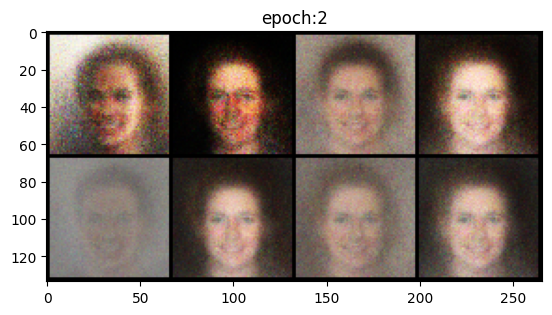

for epoch: 3/10.....batch: 1...g_loss: 3.607776403427124.....d_loss:0.46952545642852783
for epoch: 3/10.....batch: 51...g_loss: 3.0939605236053467.....d_loss:0.3892863988876343
for epoch: 3/10.....batch: 101...g_loss: 2.4280309677124023.....d_loss:0.4135357737541199
for epoch: 3/10.....batch: 151...g_loss: 2.4810032844543457.....d_loss:0.28204530477523804
for epoch: 3/10.....batch: 201...g_loss: 2.799670696258545.....d_loss:0.3538268208503723
for epoch: 3/10.....batch: 251...g_loss: 1.9434634447097778.....d_loss:0.5163742899894714
for epoch: 3/10.....batch: 301...g_loss: 2.302950859069824.....d_loss:0.35077130794525146
for epoch: 3/10.....batch: 351...g_loss: 4.149179458618164.....d_loss:0.5895472764968872
for epoch: 3/10.....batch: 401...g_loss: 2.0862181186676025.....d_loss:0.36566880345344543
for epoch: 3/10.....batch: 451...g_loss: 2.537052869796753.....d_loss:0.5394918322563171
for epoch: 3/10.....batch: 501...g_loss: 3.1314945220947266.....d_loss:0.26607051491737366
for epoch: 3/

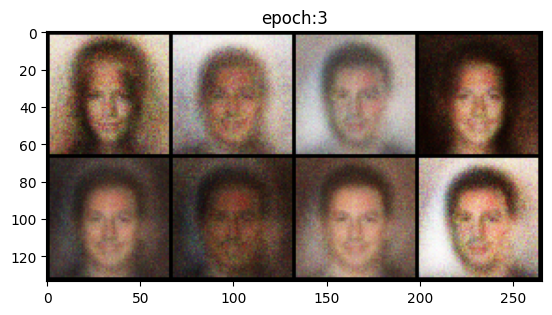

for epoch: 4/10.....batch: 1...g_loss: 2.5622034072875977.....d_loss:0.405872106552124
for epoch: 4/10.....batch: 51...g_loss: 2.4617018699645996.....d_loss:0.3708379864692688
for epoch: 4/10.....batch: 101...g_loss: 2.4822871685028076.....d_loss:0.4183078706264496
for epoch: 4/10.....batch: 151...g_loss: 2.5794565677642822.....d_loss:0.33101290464401245
for epoch: 4/10.....batch: 201...g_loss: 2.4947397708892822.....d_loss:0.3959204852581024
for epoch: 4/10.....batch: 251...g_loss: 2.5603108406066895.....d_loss:0.2736748158931732
for epoch: 4/10.....batch: 301...g_loss: 1.9727392196655273.....d_loss:0.39133375883102417
for epoch: 4/10.....batch: 351...g_loss: 2.4533612728118896.....d_loss:0.3848285675048828
for epoch: 4/10.....batch: 401...g_loss: 2.7580854892730713.....d_loss:0.24439388513565063
for epoch: 4/10.....batch: 451...g_loss: 2.4699270725250244.....d_loss:0.44346991181373596
for epoch: 4/10.....batch: 501...g_loss: 2.506948709487915.....d_loss:0.44214504957199097
for epoch:

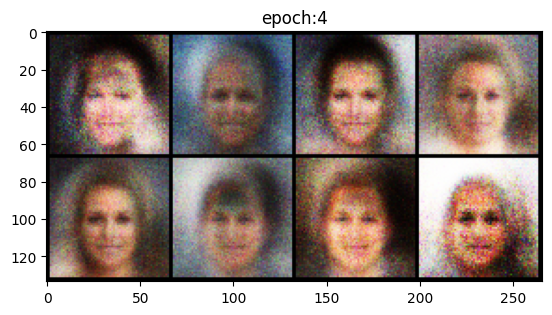

for epoch: 5/10.....batch: 1...g_loss: 2.8115036487579346.....d_loss:0.47706931829452515
for epoch: 5/10.....batch: 51...g_loss: 1.7852195501327515.....d_loss:0.5277532935142517
for epoch: 5/10.....batch: 101...g_loss: 1.7826112508773804.....d_loss:0.4816898703575134
for epoch: 5/10.....batch: 151...g_loss: 3.3877999782562256.....d_loss:0.45174431800842285
for epoch: 5/10.....batch: 201...g_loss: 2.8665709495544434.....d_loss:0.4790220260620117
for epoch: 5/10.....batch: 251...g_loss: 2.58077073097229.....d_loss:0.49110090732574463
for epoch: 5/10.....batch: 301...g_loss: 1.9904621839523315.....d_loss:0.4184046983718872
for epoch: 5/10.....batch: 351...g_loss: 2.1608800888061523.....d_loss:0.4624670147895813
for epoch: 5/10.....batch: 401...g_loss: 1.883454442024231.....d_loss:0.413423091173172
for epoch: 5/10.....batch: 451...g_loss: 1.8060041666030884.....d_loss:0.4364442825317383
for epoch: 5/10.....batch: 501...g_loss: 2.317596912384033.....d_loss:0.34600627422332764
for epoch: 5/1

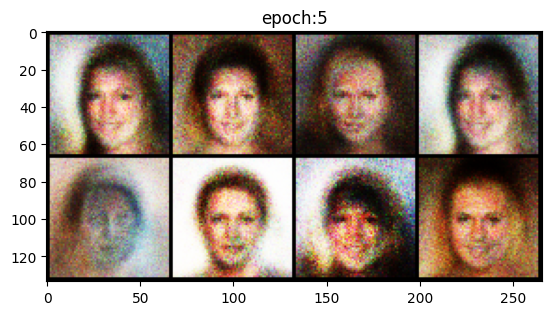

for epoch: 6/10.....batch: 1...g_loss: 2.4787847995758057.....d_loss:0.4612313508987427
for epoch: 6/10.....batch: 51...g_loss: 2.024958610534668.....d_loss:0.4267999231815338
for epoch: 6/10.....batch: 101...g_loss: 1.6881285905838013.....d_loss:0.4181327521800995
for epoch: 6/10.....batch: 151...g_loss: 1.7488566637039185.....d_loss:0.4706880450248718
for epoch: 6/10.....batch: 201...g_loss: 1.6147732734680176.....d_loss:0.5708783864974976
for epoch: 6/10.....batch: 251...g_loss: 1.601121425628662.....d_loss:0.45473045110702515
for epoch: 6/10.....batch: 301...g_loss: 2.04152512550354.....d_loss:0.49864304065704346
for epoch: 6/10.....batch: 351...g_loss: 1.7001945972442627.....d_loss:0.5220389366149902
for epoch: 6/10.....batch: 401...g_loss: 2.243732452392578.....d_loss:0.5326321125030518
for epoch: 6/10.....batch: 451...g_loss: 2.171823501586914.....d_loss:0.3388950824737549
for epoch: 6/10.....batch: 501...g_loss: 1.980345368385315.....d_loss:0.3766992688179016
for epoch: 6/10...

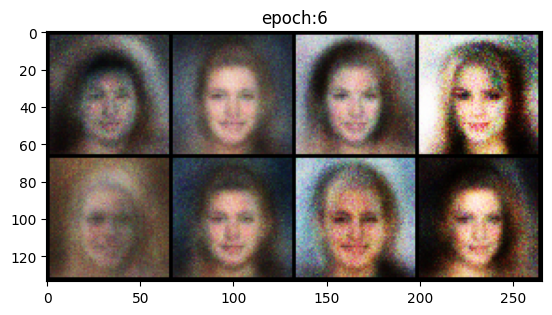

for epoch: 7/10.....batch: 1...g_loss: 2.0784802436828613.....d_loss:0.5581199526786804
for epoch: 7/10.....batch: 51...g_loss: 1.9325928688049316.....d_loss:0.4558752179145813
for epoch: 7/10.....batch: 101...g_loss: 1.5510913133621216.....d_loss:0.5434762835502625
for epoch: 7/10.....batch: 151...g_loss: 1.6771934032440186.....d_loss:0.4388974905014038
for epoch: 7/10.....batch: 201...g_loss: 1.446460247039795.....d_loss:0.5767760276794434
for epoch: 7/10.....batch: 251...g_loss: 1.4820669889450073.....d_loss:0.49699074029922485
for epoch: 7/10.....batch: 301...g_loss: 1.8310575485229492.....d_loss:0.4402299225330353
for epoch: 7/10.....batch: 351...g_loss: 1.4465980529785156.....d_loss:0.5196734070777893
for epoch: 7/10.....batch: 401...g_loss: 2.0043141841888428.....d_loss:0.4681684374809265
for epoch: 7/10.....batch: 451...g_loss: 2.227769136428833.....d_loss:0.5684751272201538
for epoch: 7/10.....batch: 501...g_loss: 1.8654109239578247.....d_loss:0.4421795606613159
for epoch: 7/1

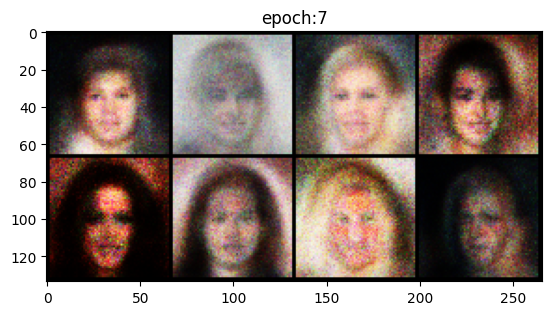

for epoch: 8/10.....batch: 1...g_loss: 1.9805983304977417.....d_loss:0.4498313069343567
for epoch: 8/10.....batch: 51...g_loss: 1.706225037574768.....d_loss:0.4809304177761078
for epoch: 8/10.....batch: 101...g_loss: 1.6204720735549927.....d_loss:0.4710080027580261
for epoch: 8/10.....batch: 151...g_loss: 1.5650124549865723.....d_loss:0.5092536211013794
for epoch: 8/10.....batch: 201...g_loss: 1.4798866510391235.....d_loss:0.5131441950798035
for epoch: 8/10.....batch: 251...g_loss: 1.7532702684402466.....d_loss:0.5292448997497559
for epoch: 8/10.....batch: 301...g_loss: 1.469800353050232.....d_loss:0.5431735515594482
for epoch: 8/10.....batch: 351...g_loss: 1.3981268405914307.....d_loss:0.5360357165336609
for epoch: 8/10.....batch: 401...g_loss: 1.789036512374878.....d_loss:0.5266615152359009
for epoch: 8/10.....batch: 451...g_loss: 1.3250757455825806.....d_loss:0.5056852102279663
for epoch: 8/10.....batch: 501...g_loss: 1.744608998298645.....d_loss:0.5022960901260376
for epoch: 8/10..

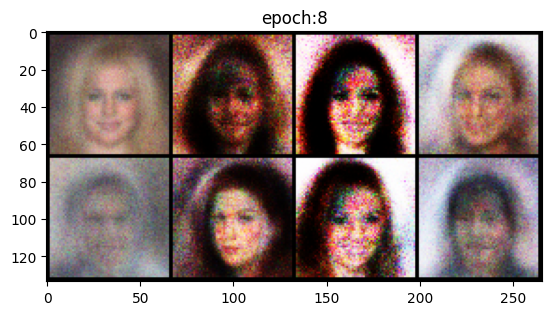

for epoch: 9/10.....batch: 1...g_loss: 1.3716832399368286.....d_loss:0.5214327573776245
for epoch: 9/10.....batch: 51...g_loss: 1.969460129737854.....d_loss:0.4654443860054016
for epoch: 9/10.....batch: 101...g_loss: 1.5569239854812622.....d_loss:0.5269875526428223
for epoch: 9/10.....batch: 151...g_loss: 1.781378984451294.....d_loss:0.47960227727890015
for epoch: 9/10.....batch: 201...g_loss: 1.7787046432495117.....d_loss:0.542777419090271
for epoch: 9/10.....batch: 251...g_loss: 1.294118046760559.....d_loss:0.5693528652191162
for epoch: 9/10.....batch: 301...g_loss: 1.7766915559768677.....d_loss:0.46910056471824646
for epoch: 9/10.....batch: 351...g_loss: 1.6450140476226807.....d_loss:0.5049261450767517
for epoch: 9/10.....batch: 401...g_loss: 1.4535702466964722.....d_loss:0.5032391548156738
for epoch: 9/10.....batch: 451...g_loss: 1.6907340288162231.....d_loss:0.6289098262786865
for epoch: 9/10.....batch: 501...g_loss: 1.670580506324768.....d_loss:0.4725363552570343
for epoch: 9/10.

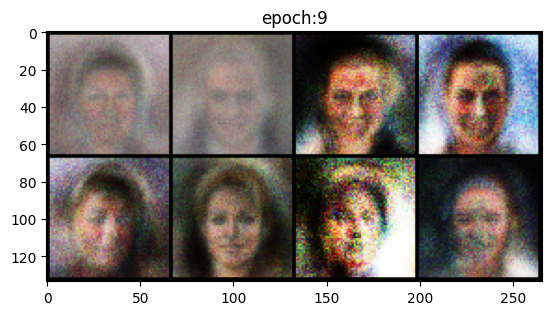

for epoch: 10/10.....batch: 1...g_loss: 1.4780513048171997.....d_loss:0.5934679508209229
for epoch: 10/10.....batch: 51...g_loss: 1.2126730680465698.....d_loss:0.5601821541786194
for epoch: 10/10.....batch: 101...g_loss: 1.4516226053237915.....d_loss:0.49173834919929504
for epoch: 10/10.....batch: 151...g_loss: 1.530794382095337.....d_loss:0.5758357048034668
for epoch: 10/10.....batch: 201...g_loss: 1.2197848558425903.....d_loss:0.5397862792015076
for epoch: 10/10.....batch: 251...g_loss: 1.4506394863128662.....d_loss:0.6203827857971191
for epoch: 10/10.....batch: 301...g_loss: 1.5062823295593262.....d_loss:0.5360151529312134
for epoch: 10/10.....batch: 351...g_loss: 1.434964656829834.....d_loss:0.5559453964233398
for epoch: 10/10.....batch: 401...g_loss: 1.402633547782898.....d_loss:0.5883261561393738
for epoch: 10/10.....batch: 451...g_loss: 1.4711494445800781.....d_loss:0.5924059152603149
for epoch: 10/10.....batch: 501...g_loss: 1.5511444807052612.....d_loss:0.49305203557014465
for

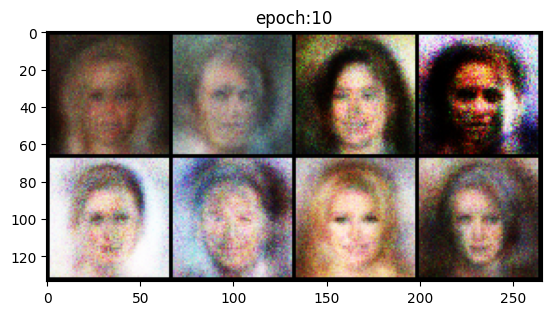

In [52]:
train(generator,discriminator,dataloader)